# Hypothesis 3 — AI agent consulting humans more restores balance

When fast agents are encouraged to consult slow agents more often, slow-origin information can
propagate and compete with fast-origin information. It is a sign of a costly signal.


## 0. Initial Config

These 4 terms are the probabilities associated with adoption-propagation cycle. `P_FF`, `P_FS`, `P_SF`, `P_SS` are the four probabilities under test.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

FAST, SLOW = 0, 1          # agent type (fixed)
F, S = 0, 1                # information label (changes)


P_FF = 0.1     # fast -> fast    
P_FS = 0.1     # fast -> slow    
P_SF = 0.1     # slow -> fast    
P_SS = 0.1     # slow -> slow    

RHO = 3        # speed ratio  dT_s / dT_f

# experiment settings
GRID   = 40    # n x n lattice, half fast / half slow
SEEDS  = 300   # independent runs; C is an expectation over these
N_TAUS = 25    # horizon in units of the mixing time tau  (T >> tau = "appropriately long")
T_MIN, T_MAX = 30, 400
N_JOBS = -1    # joblib parallelism

N = GRID ** 2
OFFSETS = [(di, dj) for di in (-1, 0, 1) for dj in (-1, 0, 1) if (di, dj) != (0, 0)]


def P_matrix(p_ff=P_FF, p_fs=P_FS, p_sf=P_SF, p_ss=P_SS):
    """P[propagator type, adopter type]."""
    return np.array([[p_ff, p_fs],
                     [p_sf, p_ss]], dtype=float)


def C_predicted(rho, P):
    """C = r_s P_sf / (r_f P_fs) = P_sf / (rho P_fs)."""
    return P[SLOW, FAST] / (rho * P[FAST, SLOW])


def tau_ticks(rho, P, k=8, f=0.5):
    """Mixing time in fast ticks: 1 / (k (f r_f P_fs + (1-f) r_s P_sf))."""
    return 1.0 / (k * (f * P[FAST, SLOW] + (1 - f) * (1.0 / rho) * P[SLOW, FAST]))


def horizon(rho, P):
    return int(np.clip(np.ceil(N_TAUS * tau_ticks(rho, P)), T_MIN, T_MAX))




## 1. The model

Same lattice and push dynamics as Hypothesis 1.

In [2]:
def make_grid(n, rng):
    """n x n grid, half fast / half slow at random. Everyone starts holding their own type's label."""
    kind = np.full(n * n, SLOW, dtype=int)
    kind[: n * n // 2] = FAST
    rng.shuffle(kind)
    kind = kind.reshape(n, n)
    return kind, np.where(kind == FAST, F, S)


def inside(n, di, dj):
    """Slices so grid[src] offers to grid[dst] for offset (di, dj), staying inside the grid."""
    r0, r1 = max(0, -di), n - max(0, di)
    c0, c1 = max(0, -dj), n - max(0, dj)
    return ((slice(r0, r1), slice(c0, c1)),
            (slice(r0 + di, r1 + di), slice(c0 + dj, c1 + dj)))


def run(n, rho, ticks, P, seed, sequential=True):
   
    rng = np.random.default_rng(seed)
    kind, state = make_grid(n, rng)
    phase = rng.integers(0, rho, size=(n, n))
    order = list(range(len(OFFSETS)))

    for t in range(ticks):
        active = (kind == FAST) | ((t + phase) % rho == 0)
        if sequential:
            rng.shuffle(order)
            for oi in order:
                di, dj = OFFSETS[oi]
                src, dst = inside(n, di, dj)
                accepted = active[src] & (rng.random(active[src].shape) < P[kind[src], kind[dst]])
                target = state[dst]
                target[accepted] = state[src][accepted]
        else:
            new_state = state.copy()
            for di, dj in OFFSETS:
                src, dst = inside(n, di, dj)
                accepted = active[src] & (rng.random(active[src].shape) < P[kind[src], kind[dst]])
                target = new_state[dst]
                target[accepted] = state[src][accepted]
            state = new_state
    return np.count_nonzero(state == S)


def C_index(rho, P, n=GRID, seeds=SEEDS, sequential=True, boot=2000, rng=None):
    
    T = horizon(rho, P)
    nS = np.array(Parallel(n_jobs=N_JOBS)(
        delayed(run)(n, rho, T, P, s, sequential) for s in range(seeds)), dtype=float)
    Ntot = n * n
    rng = np.random.default_rng(0) if rng is None else rng
    draws = nS[rng.integers(0, nS.size, size=(boot, nS.size))].mean(axis=1)
    lo, hi = np.percentile(draws / (Ntot - draws), [2.5, 97.5])
    return nS.mean() / (Ntot - nS.mean()), lo, hi, T


C, lo, hi, T = C_index(RHO, P_matrix())
print(f"baseline: C = {C:.4f}  95% CI [{lo:.4f}, {hi:.4f}]   "
      f"predicted {C_predicted(RHO, P_matrix()):.4f}   (T = {T} ticks)")

baseline: C = 0.3249  95% CI [0.3129, 0.3372]   predicted 0.3333   (T = 47 ticks)


## 2. Checking the update rule before trusting any of it



In [3]:
def n_fast_label(n, rho, ticks, P, seed, sequential):
    return 1.0 - run(n, rho, ticks, P, seed, sequential) / (n * n)


for rho, p_sf, p_fs in [(3, 0.3, 0.1), (10, 1.0, 0.1), (100, 1.0, 0.01)]:
    P = P_matrix(p_sf=p_sf, p_fs=p_fs)
    row = f"{rho:5d}{p_sf:7.2f}{p_fs:7.3f}   "
    for seq in (False, True):
        vals = np.array(Parallel(n_jobs=N_JOBS)(
            delayed(n_fast_label)(GRID, rho, 30, P, s, seq) for s in range(400)))
        m, se = vals.mean(), vals.std(ddof=1) / np.sqrt(vals.size)
        row += f"{m:.4f}±{se:.4f} ({abs(m - 0.5) / se:4.1f}σ)".rjust(24)
    print(row)



    3   0.30  0.100      0.5112±0.0025 ( 4.5σ)   0.4943±0.0030 ( 1.9σ)
   10   1.00  0.100      0.5212±0.0030 ( 7.1σ)   0.5000±0.0032 ( 0.0σ)
  100   1.00  0.010      0.5298±0.0017 (17.7σ)   0.5022±0.0020 ( 1.1σ)


## 3. Experiment A — sweep the consultation lever $P_{sf}$


 rho   P_sf     T   C observed              95% CI  C predicted  ratio   balance
   1   0.10    32       0.9831   [ 0.954,  1.012]       1.0000   0.98   
   1   0.20    30       2.0386   [ 1.974,  2.109]       2.0000   1.02   C >= 1  <<<
   1   0.30    30       3.0924   [ 2.976,  3.212]       3.0000   1.03   C >= 1  <<<
   1   0.50    30       5.6568   [ 5.391,  5.943]       5.0000   1.13   C >= 1  <<<
   1   0.75    30       8.7895   [ 8.257,  9.350]       7.5000   1.17   C >= 1  <<<
   1   1.00    30      11.5402   [10.838, 12.401]      10.0000   1.15   C >= 1  <<<
   3   0.10    47       0.3249   [ 0.313,  0.337]       0.3333   0.97   
   3   0.20    38       0.6713   [ 0.651,  0.691]       0.6667   1.01   
   3   0.30    32       1.0175   [ 0.990,  1.047]       1.0000   1.02   C >= 1  <<<
   3   0.50    30       1.7594   [ 1.709,  1.812]       1.6667   1.06   C >= 1  <<<
   3   0.75    30       2.6520   [ 2.572,  2.736]       2.5000   1.06   C >= 1  <<<
   3   1.00    30       3.58

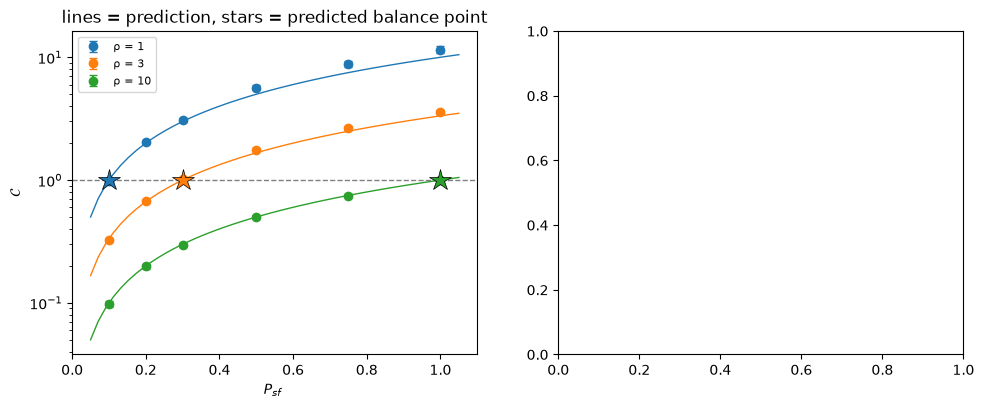

In [8]:
SWEEP_RHOS = [1, 3, 10] # arbitrary sweep
SWEEP_PSF  = [0.1, 0.2, 0.3, 0.5, 0.75, 1.0]

results = {}
print(f"{'rho':>4}{'P_sf':>7}{'T':>6}{'C observed':>13}{'95% CI':>20}{'C predicted':>13}{'ratio':>7}   balance")
for rho in SWEEP_RHOS:
    row = []
    for p_sf in SWEEP_PSF:
        P = P_matrix(p_sf=p_sf)
        C, lo, hi, T = C_index(rho, P)
        row.append((C, lo, hi))
        pred = C_predicted(rho, P)
        print(f"{rho:4d}{p_sf:7.2f}{T:6d}{C:13.4f}   [{lo:6.3f},{hi:7.3f}]{pred:13.4f}"
              f"{C / pred:7.2f}   {'C >= 1  <<<' if C >= 1 else ''}")
    results[rho] = np.array(row)

fig, ax = plt.subplots(1,2, figsize=(11.5, 4.2))
line = np.linspace(0.05, 1.05, 50)
for i, rho in enumerate(SWEEP_RHOS):
    C, lo, hi = results[rho].T
    ax[0].plot(line, line / (rho * P_FS), color=f"C{i}", linewidth=1)
    ax[0].errorbar(SWEEP_PSF, C, yerr=[C - lo, hi - C], fmt="o", color=f"C{i}",
                   capsize=3, label=f"ρ = {rho}")
    ax[0].plot(rho * P_FS, 1.0, marker="*", color=f"C{i}", markersize=16,
               markeredgecolor="k", markeredgewidth=0.5, zorder=5)
ax[0].axhline(1, color="grey", linestyle="--", linewidth=1)
ax[0].set_yscale("log")
ax[0].set_xlabel(r"$P_{sf}$ ")
ax[0].set_ylabel(r"$\mathcal{C}$")
ax[0].set_title("lines = prediction, stars = predicted balance point")
ax[0].legend(fontsize=8)



### 4. Experiment B: Changing both $P_{sf}$ and $P_{fs}$ at once
 
Whichcombinations of the two cross-type probabilities reach $\mathcal{C} \geq 1$?

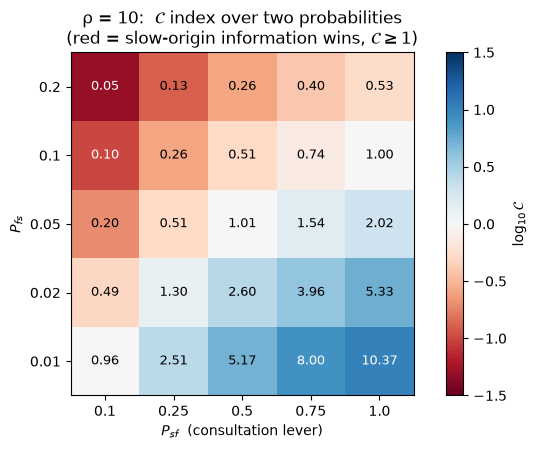

11 of 25 combinations reach C >= 1 at rho = 10.
predicted boundary: P_sf >= rho * P_fs = 10 * P_fs


In [11]:
HEAT_RHO = 10
HEAT_PSF = [0.1, 0.25, 0.5, 0.75, 1.0]
HEAT_PFS = [0.2, 0.1, 0.05, 0.02, 0.01]

heat = np.zeros((len(HEAT_PFS), len(HEAT_PSF)))
for i, p_fs in enumerate(HEAT_PFS):
    for j, p_sf in enumerate(HEAT_PSF):
        heat[i, j] = C_index(HEAT_RHO, P_matrix(p_sf=p_sf, p_fs=p_fs), seeds=150, boot=1)[0]
# plots
plt.figure(figsize=(6.8, 4.6))
plt.imshow(np.log10(heat), cmap="RdBu", vmin=-1.5, vmax=1.5, origin="upper")
plt.colorbar(label=r"$\log_{10} \mathcal{C}$")
for i in range(len(HEAT_PFS)):
    for j in range(len(HEAT_PSF)):
        plt.text(j, i, f"{heat[i, j]:.2f}", ha="center", va="center",
                 fontsize=9, color="k" if abs(np.log10(heat[i, j])) < 0.9 else "w")
plt.xticks(range(len(HEAT_PSF)), HEAT_PSF); plt.yticks(range(len(HEAT_PFS)), HEAT_PFS)
plt.xlabel(r"$P_{sf}$  (consultation lever)"); plt.ylabel(r"$P_{fs}$")
plt.title(f"ρ = {HEAT_RHO}:  $\mathcal{{C}}$ index over two probabilities\n"
          r"(red = slow-origin information wins, $\mathcal{C} \geq 1$)")
plt.tight_layout(); plt.show()

reach = heat >= 1
print(f"{reach.sum()} of {reach.size} combinations reach C >= 1 at rho = {HEAT_RHO}.")
print(f"predicted boundary: P_sf >= rho * P_fs = {HEAT_RHO} * P_fs")